### Честная сборка полного графа

In [ ]:
from yggdrasill import Hypergraph
from yggdrasill.engine.edge import Edge
from yggdrasill.integrations.diffusers import contracts as C
from yggdrasill.integrations.diffusers.model_store import ModelStore
from yggdrasill.integrations.diffusers.registry import register_diffusion_nodes

register_diffusion_nodes()

store = ModelStore.default()
repo = "stabilityai/stable-diffusion-xl-base-1.0"
sdxl_keys = [
    "tokenizer", "tokenizer_2", "text_encoder", "text_encoder_2",
    "unet", "vae", "scheduler",
]
components = store.load_components_by_keys(
    "sdxl", sdxl_keys, repo, variant="fp16", torch_dtype="float16",
)

graph = Hypergraph(name="MySDXLGraph")
cfg = {
    "height": 1024,
    "width": 1024,
    "num_inference_steps": 50,
    "device": "cuda",
    "guidance_scale": 7.5,
}

graph.add_node(
    "tokenizer",
    type="sdxl/tokenizer",
    config={
        "tokenizer": components["tokenizer"],
        "tokenizer_2": components["tokenizer_2"],
    },
    auto_connect=False,
)
graph.add_node(
    "prompt_enc",
    type="sdxl/prompt_encoder",
    config={
        "text_encoder": components["text_encoder"],
        "text_encoder_2": components["text_encoder_2"],
    },
    auto_connect=False,
)
graph.add_node(
    "added_cond",
    type="sdxl/added_conditioning",
    config={
        "original_size": (cfg["height"], cfg["width"]),
        "target_size": (cfg["height"], cfg["width"]),
        "crops_coords_top_left": (0, 0),
        "requires_aesthetics_score": False,
    },
    auto_connect=False,
)
graph.add_node(
    "sched_setup",
    type="sdxl/scheduler_setup",
    config={
        "scheduler": components["scheduler"],
        "num_inference_steps": cfg["num_inference_steps"],
        "device": cfg["device"],
    },
    auto_connect=False,
)
graph.add_node(
    "latent_init",
    type="sdxl/latent_init",
    config={
        "height": cfg["height"],
        "width": cfg["width"],
        "device": cfg["device"],
        "dtype": "float16",
    },
    auto_connect=False,
)
graph.add_node(
    "unet",
    type="sdxl/unet",
    config={
        "unet": components["unet"],
        "guidance_scale": cfg["guidance_scale"],
    },
    auto_connect=False,
)
graph.add_node(
    "sched_step",
    type="sdxl/scheduler_step",
    config={"scheduler": components["scheduler"]},
    auto_connect=False,
)
graph.add_node(
    "vae_decode",
    type="sdxl/vae_decode",
    config={"vae": components["vae"], "output_type": "pil"},
    auto_connect=False,
)

# Рёбра: dual tokenizer → encoder, added conditioning → UNet, цикл scheduler ↔ UNet
graph.add_edge(Edge("tokenizer", C.PORT_INPUT_IDS, "prompt_enc", C.PORT_INPUT_IDS))
graph.add_edge(Edge("tokenizer", C.PORT_INPUT_IDS_2, "prompt_enc", C.PORT_INPUT_IDS_2))
graph.add_edge(Edge("tokenizer", C.PORT_NEGATIVE_INPUT_IDS, "prompt_enc", C.PORT_NEGATIVE_INPUT_IDS))
graph.add_edge(Edge("tokenizer", C.PORT_NEGATIVE_INPUT_IDS_2, "prompt_enc", C.PORT_NEGATIVE_INPUT_IDS_2))
graph.add_edge(Edge("sched_setup", C.PORT_SCHEDULER_STATE, "latent_init", C.PORT_SCHEDULER_STATE))
# Для scale_model_input в UNet нужен scheduler_state (актуальный SDXLUNetNode).
# Если порт не найден — старая копия модуля в памяти ядра: Kernel → Restart.
_unet = graph.get_node("unet")
if _unet is not None and _unet.get_port(C.PORT_SCHEDULER_STATE) is not None:
    graph.add_edge(Edge("sched_setup", C.PORT_SCHEDULER_STATE, "unet", C.PORT_SCHEDULER_STATE))
else:
    import warnings
    warnings.warn(
        "UNet не объявляет порт scheduler_state — пропускаем sched_setup→unet. "
        "Перезапустите kernel Jupyter после обновления yggdrasill."
    )

graph.add_edge(Edge("prompt_enc", C.PORT_PROMPT_EMBEDS, "unet", C.PORT_PROMPT_EMBEDS))
graph.add_edge(Edge("prompt_enc", C.PORT_NEGATIVE_PROMPT_EMBEDS, "unet", C.PORT_NEGATIVE_PROMPT_EMBEDS))
graph.add_edge(Edge("prompt_enc", C.PORT_POOLED_PROMPT_EMBEDS, "added_cond", C.PORT_POOLED_PROMPT_EMBEDS))
graph.add_edge(
    Edge("prompt_enc", C.PORT_NEGATIVE_POOLED_PROMPT_EMBEDS, "added_cond", C.PORT_NEGATIVE_POOLED_PROMPT_EMBEDS)
)
graph.add_edge(
    Edge("prompt_enc", C.PORT_NEGATIVE_POOLED_PROMPT_EMBEDS, "unet", C.PORT_NEGATIVE_POOLED_PROMPT_EMBEDS)
)
graph.add_edge(Edge("added_cond", C.PORT_ADD_TEXT_EMBEDS, "unet", C.PORT_ADD_TEXT_EMBEDS))
graph.add_edge(Edge("added_cond", C.PORT_ADD_TIME_IDS, "unet", C.PORT_ADD_TIME_IDS))
graph.add_edge(Edge("added_cond", C.PORT_NEGATIVE_ADD_TIME_IDS, "unet", C.PORT_NEGATIVE_ADD_TIME_IDS))
graph.add_edge(Edge("latent_init", C.PORT_LATENTS, "unet", C.PORT_LATENTS))
graph.add_edge(Edge("latent_init", C.PORT_LATENTS, "sched_step", C.PORT_LATENTS))
graph.add_edge(Edge("latent_init", C.PORT_TIMESTEP, "unet", C.PORT_TIMESTEP))
graph.add_edge(Edge("latent_init", C.PORT_TIMESTEP, "sched_step", C.PORT_TIMESTEP))
graph.add_edge(Edge("unet", C.PORT_NOISE_PRED, "sched_step", C.PORT_NOISE_PRED))
graph.add_edge(Edge("sched_step", "next_latent", "unet", C.PORT_LATENTS))
graph.add_edge(Edge("sched_step", "next_latent", "sched_step", C.PORT_LATENTS))
graph.add_edge(Edge("sched_step", "next_timestep", "unet", C.PORT_TIMESTEP))
graph.add_edge(Edge("sched_step", "next_timestep", "sched_step", C.PORT_TIMESTEP))
graph.add_edge(Edge("sched_step", "next_latent", "vae_decode", C.PORT_LATENTS))

graph.expose_input("tokenizer", C.PORT_PROMPT, C.PORT_PROMPT)
graph.expose_input("tokenizer", C.PORT_NEGATIVE_PROMPT, C.PORT_NEGATIVE_PROMPT)
graph.expose_input("tokenizer", C.PORT_PROMPT_2, C.PORT_PROMPT_2)
graph.expose_output("vae_decode", C.PORT_DECODED_IMAGE, C.PORT_OUTPUT_IMAGE)
graph.metadata["num_loop_steps"] = cfg["num_inference_steps"]

graph.to("cuda")

In [ ]:
output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### Создание через специализированный `DiffusionGraphBuilder`


In [ ]:
from yggdrasill import DiffusionGraphBuilder

repo = "stabilityai/stable-diffusion-xl-base-1.0"

builder = DiffusionGraphBuilder(name="MySDXLGraph")
builder.add_component("Backbone", "sdxl.unet", pretrained=repo)
builder.add_component("Scheduler", "sdxl.scheduler", pretrained=repo)
builder.add_component("Tokenizer1", "sdxl.tokenizer_1", pretrained=repo)
builder.add_component("Tokenizer2", "sdxl.tokenizer_2", pretrained=repo)
builder.add_component("TextEncoder1", "sdxl.text_encoder_1", pretrained=repo)
builder.add_component("TextEncoder2", "sdxl.text_encoder_2", pretrained=repo)
builder.add_component("Autoencoder", "sdxl.vae", pretrained=repo)
builder.to("cuda")

In [ ]:
output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### Использование в 2 строчки кода

In [ ]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sdxl_text2img", device="cuda")

output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### Добавление новых компонент в граф

In [ ]:
from yggdrasill import Hypergraph, DiffusionGraphBuilder

graph = Hypergraph.from_template("sdxl_text2img", device="cuda")
builder = DiffusionGraphBuilder(graph)
builder.add_component("ControlNetCanny", "sdxl.controlnet", pretrained="diffusers/controlnet-canny-sdxl-1.0")
builder.add_component("ControlNetDepth", "sdxl.controlnet", pretrained="diffusers/controlnet-depth-sdxl-1.0")
builder.add_component(
    "IPAdapter", "sdxl.ipadapter", pretrained="h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter_sdxl.bin"
)
builder.to("cuda")

In [ ]:
output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    controlnet_image={
        "ControlNetCanny": "https://media.licdn.com/dms/image/v2/C5112AQExoUiRNUfNyg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1582133550471?e=2147483647&v=beta&t=SAvSWpaMfcrgAB_tWPHZkrvFEGRXKSKo-fuiORZU16I",
        "ControlNetDepth": "https://www.cyanilux.com/tutorials/depth/Preview.png",
    },
    controlnet_conditioning_scale={
        "ControlNetCanny": 0.9,
        "ControlNetDepth": 0.9,
    },
    ip_adapter_image={
        "IPAdapter": "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQWwG5ox4lq_Kiq0g8dmSb1hsq-dnNibEtd2w&s",
    },
    ip_adapter_conditioning_scale={
        "IPAdapter": 0.5,
    },
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

In [ ]:
from yggdrasill import DiffusionGraphBuilder

repo = "stabilityai/stable-diffusion-xl-base-1.0"

builder = DiffusionGraphBuilder(name="MySDXLGraph")
builder.add_component("Backbone", "sdxl.unet", pretrained=repo)
builder.add_component("Scheduler", "sdxl.scheduler", pretrained=repo)
builder.add_component("Tokenizer1", "sdxl.tokenizer_1", pretrained=repo)
builder.add_component("Tokenizer2", "sdxl.tokenizer_2", pretrained=repo)
builder.add_component("TextEncoder1", "sdxl.text_encoder_1", pretrained=repo)
builder.add_component("TextEncoder2", "sdxl.text_encoder_2", pretrained=repo)
builder.add_component("Autoencoder", "sdxl.vae", pretrained=repo)
builder.add_component("ControlNetCanny", "sdxl.controlnet", pretrained="diffusers/controlnet-canny-sdxl-1.0")
builder.add_component("ControlNetDepth", "sdxl.controlnet", pretrained="diffusers/controlnet-depth-sdxl-1.0")
builder.add_component(
    "IPAdapter", "sdxl.ipadapter", pretrained="h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter_sdxl.bin"
)
builder.to("cuda")

In [ ]:
output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    controlnet_image={
        "ControlNetCanny": "https://media.licdn.com/dms/image/v2/C5112AQExoUiRNUfNyg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1582133550471?e=2147483647&v=beta&t=SAvSWpaMfcrgAB_tWPHZkrvFEGRXKSKo-fuiORZU16I",
        "ControlNetDepth": "https://www.cyanilux.com/tutorials/depth/Preview.png",
    },
    controlnet_conditioning_scale={
        "ControlNetCanny": 0.9,
        "ControlNetDepth": 0.9,
    },
    ip_adapter_image={
        "IPAdapter": "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQWwG5ox4lq_Kiq0g8dmSb1hsq-dnNibEtd2w&s",
    },
    ip_adapter_conditioning_scale={
        "IPAdapter": 0.5,
    },
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### Замена компонентов в графе

In [ ]:
from yggdrasill import Hypergraph, DiffusionGraphBuilder

graph = Hypergraph.from_template("sdxl_text2img", device="cuda")
builder = DiffusionGraphBuilder(graph)
builder.replace_component("Backbone", "sdxl.unet", pretrained="RunDiffusion/Juggernaut-XL-v9")

In [ ]:
output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

In [ ]:
builder.replace_component("Scheduler", "sdxl.scheduler", scheduler_type="dpm_solver")

output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

In [ ]:
builder.add_component("ControlNetCanny", "sdxl.controlnet", pretrained="diffusers/controlnet-canny-sdxl-1.0")

output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    controlnet_image={
        "ControlNetCanny": "https://media.licdn.com/dms/image/v2/C5112AQExoUiRNUfNyg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1582133550471?e=2147483647&v=beta&t=SAvSWpaMfcrgAB_tWPHZkrvFEGRXKSKo-fuiORZU16I",
    },
    controlnet_conditioning_scale={
        "ControlNetCanny": 0.9,
    },
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

In [ ]:
builder.add_component("IPAdapter", "sdxl.ipadapter", pretrained="h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter_sdxl.bin")

output = builder.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    # controlnet_image={
    #     "ControlNetCanny": "https://media.licdn.com/dms/image/v2/C5112AQExoUiRNUfNyg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1582133550471?e=2147483647&v=beta&t=SAvSWpaMfcrgAB_tWPHZkrvFEGRXKSKo-fuiORZU16I",
    # },
    # controlnet_conditioning_scale={
    #     "ControlNetCanny": 0.9,
    # },
    ip_adapter_image={
        "IPAdapter": "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQWwG5ox4lq_Kiq0g8dmSb1hsq-dnNibEtd2w&s",
    },
    ip_adapter_conditioning_scale={
        "IPAdapter": 0.5,
    },
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

In [ ]:
builder.add_component("ControlNetScribble", "sdxl.controlnet", pretrained="xinsir/controlnet-scribble-sdxl-1.0")

builder.add_component("IPAdapter", "sdxl.ipadapter", pretrained="h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter_sdxl.bin")

output = builder.run(
    prompt="A woman with a red dress",
    negative_prompt="blurry",
    controlnet_image={
        "ControlNetScribble": "https://huggingface.co/takuma104/controlnet_dev/resolve/main/gen_compare/control_images/converted/control_vermeer_scribble.png",
    },
    controlnet_conditioning_scale={
        "ControlNetScribble": 0.9,
    },
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### Проверка работы img2img

In [ ]:
from yggdrasill import Hypergraph, DiffusionGraphBuilder

graph = Hypergraph.from_template("sdxl_img2img", device="cuda")
builder = DiffusionGraphBuilder(graph)
builder.replace_component("Backbone", "sdxl.unet", pretrained="RunDiffusion/Juggernaut-XL-v9")
graph = builder.graph

output = graph.run(
    prompt="A photo of an astronaut riding a horse on mars",
    negative_prompt="blurry",
    image="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRtxLSt4-D6-Tps1EIHblCehsP0yB5evpwylw&s",
    strength=0.9,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### Проверка работы inpaint

In [ ]:
from yggdrasill import Hypergraph, DiffusionGraphBuilder

graph = Hypergraph.from_template("sdxl_inpaint", device="cuda")

# builder = DiffusionGraphBuilder(graph)
# builder.replace_component("Backbone", "sdxl.unet", pretrained="RunDiffusion/Juggernaut-XL-v9")
# graph = builder.graph

output = graph.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=1.0,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### Проверка работы универсального графа

In [ ]:
from yggdrasill import DiffusionGraphBuilder

builder = DiffusionGraphBuilder(name="MySDXLGraph")
builder.add_component("Backbone", "sdxl.unet", pretrained="RunDiffusion/Juggernaut-XL-v9")
builder.add_component("Scheduler", "sdxl.scheduler", pretrained="RunDiffusion/Juggernaut-XL-v9")
builder.add_component("Tokenizer1", "sdxl.tokenizer_1", pretrained="RunDiffusion/Juggernaut-XL-v9")
builder.add_component("Tokenizer2", "sdxl.tokenizer_2", pretrained="RunDiffusion/Juggernaut-XL-v9")
builder.add_component("TextEncoder1", "sdxl.text_encoder_1", pretrained="RunDiffusion/Juggernaut-XL-v9")
builder.add_component("TextEncoder2", "sdxl.text_encoder_2", pretrained="RunDiffusion/Juggernaut-XL-v9")
builder.add_component("Autoencoder", "sdxl.vae", pretrained="RunDiffusion/Juggernaut-XL-v9")
builder.to("cuda")

In [ ]:
output = builder.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=0.9,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### Проверка что отдельные пайплайны выполняют только свою задачу 

In [ ]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sdxl_text2img", device="cuda")

output = graph.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=0.9,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

In [ ]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sdxl_img2img", device="cuda")

output = graph.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=0.9,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

In [ ]:
from yggdrasill import Hypergraph

graph = Hypergraph.from_template("sdxl_inpaint", device="cuda")

output = graph.run(
    prompt="concept art digital painting of an elven castle, inspired by lord of the rings, highly detailed, 8k",
    negative_prompt="blurry",
    image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint.png",
    mask_image="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/inpaint_mask.png",
    strength=0.9,
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

# Полная поддержка IP-Adapter

In [ ]:
from yggdrasill import DiffusionGraphBuilder

builder = DiffusionGraphBuilder.from_template("sdxl_text2img", device="cuda")
builder.add_component(
    "IPAdapter", "sdxl.ipadapter", pretrained="h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter_sdxl.bin"
)

output = builder.run(
    prompt="a polar bear sitting in a chair drinking a milkshake",
    negative_prompt="deformed, ugly, wrong proportion, low res, bad anatomy, worst quality, low quality",
    ip_adapter_image={
        "IPAdapter": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_adapter_diner.png"
    },
    ip_adapter_conditioning_scale={
        "IPAdapter": 0.09,
    },
    seed=42,
    width=1024,
    height=1024,
)

output.images[0]

### IP-Adapter: предвычисленные эмбеддинги

In [ ]:
from diffusers.utils import load_image
import torch

from yggdrasill.integrations.diffusers import prepare_ip_adapter_image_embeds

ref = load_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_adapter_diner.png"
)

embeds = prepare_ip_adapter_image_embeds(
    builder.graph,
    ref,
    device="cuda",
    num_images_per_prompt=1,
    do_classifier_free_guidance=True,
)
torch.save(embeds, "image_embeds.ipadpt")

loaded = torch.load("image_embeds.ipadpt", map_location="cuda")
# один слот IP-Adapter → один тензор в списке
emb_arg = loaded[0] if len(loaded) == 1 else loaded

output = builder.run(
    prompt="a polar bear sitting in a chair drinking a milkshake",
    negative_prompt="deformed, ugly, wrong proportion, low res, bad anatomy, worst quality, low quality",
    ip_adapter_image_embeds={"IPAdapter": emb_arg},
    ip_adapter_conditioning_scale={"IPAdapter": 0.8},
    guidance_scale=7.5,
    num_inference_steps=30,
    num_images_per_prompt=1,
    seed=42,
    width=1024,
    height=1024,
)
output.images[0]


### Маски с IP-Adapter

In [ ]:
from yggdrasill import DiffusionGraphBuilder

mask_builder = DiffusionGraphBuilder.from_template("sdxl_text2img", device="cuda")
mask_builder.add_component(
    "IPAdapterFace",
    "sdxl.ipadapter",
    pretrained="h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter-plus-face_sdxl_vit-h.safetensors",
)

out = mask_builder.run(
    prompt="2 girls",
    width=1024,
    height=1024,
    negative_prompt="monochrome, lowres, bad anatomy, worst quality, low quality",
    ip_adapter_image={"IPAdapterFace": [
        "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_girl1.png",
        "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_girl2.png",
    ]},
    ip_adapter_mask_images=[
        "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_mask1.png",
        "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/ip_mask_mask2.png",
    ],
    ip_adapter_conditioning_scale={"IPAdapterFace": [0.7, 0.7]},
    seed=42,
)

out.images[0]

### Face models

### Multiple IP-Adapters

[yggdrasill] Loading components from stabilityai/stable-diffusion-xl-base-1.0: tokenizer, tokenizer_2, text_encoder, text_encoder_2, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from stabilityai/stable-diffusion-xl-base-1.0/tokenizer
[yggdrasill] Component cache hit: CLIPTokenizer from stabilityai/stable-diffusion-xl-base-1.0/tokenizer_2
[yggdrasill] Component cache hit: CLIPTextModel from stabilityai/stable-diffusion-xl-base-1.0/text_encoder
[yggdrasill] Component cache hit: CLIPTextModelWithProjection from stabilityai/stable-diffusion-xl-base-1.0/text_encoder_2
[yggdrasill] Component cache hit: UNet2DConditionModel from stabilityai/stable-diffusion-xl-base-1.0/unet
[yggdrasill] Component cache hit: AutoencoderKL from stabilityai/stable-diffusion-xl-base-1.0/vae
[yggdrasill] Component cache hit: EulerDiscreteScheduler from stabilityai/stable-diffusion-xl-base-1.0/scheduler
[yggdrasill] Loaded 7/7 components: tokenizer, tokenizer_2, text_encoder, text_encoder_2,

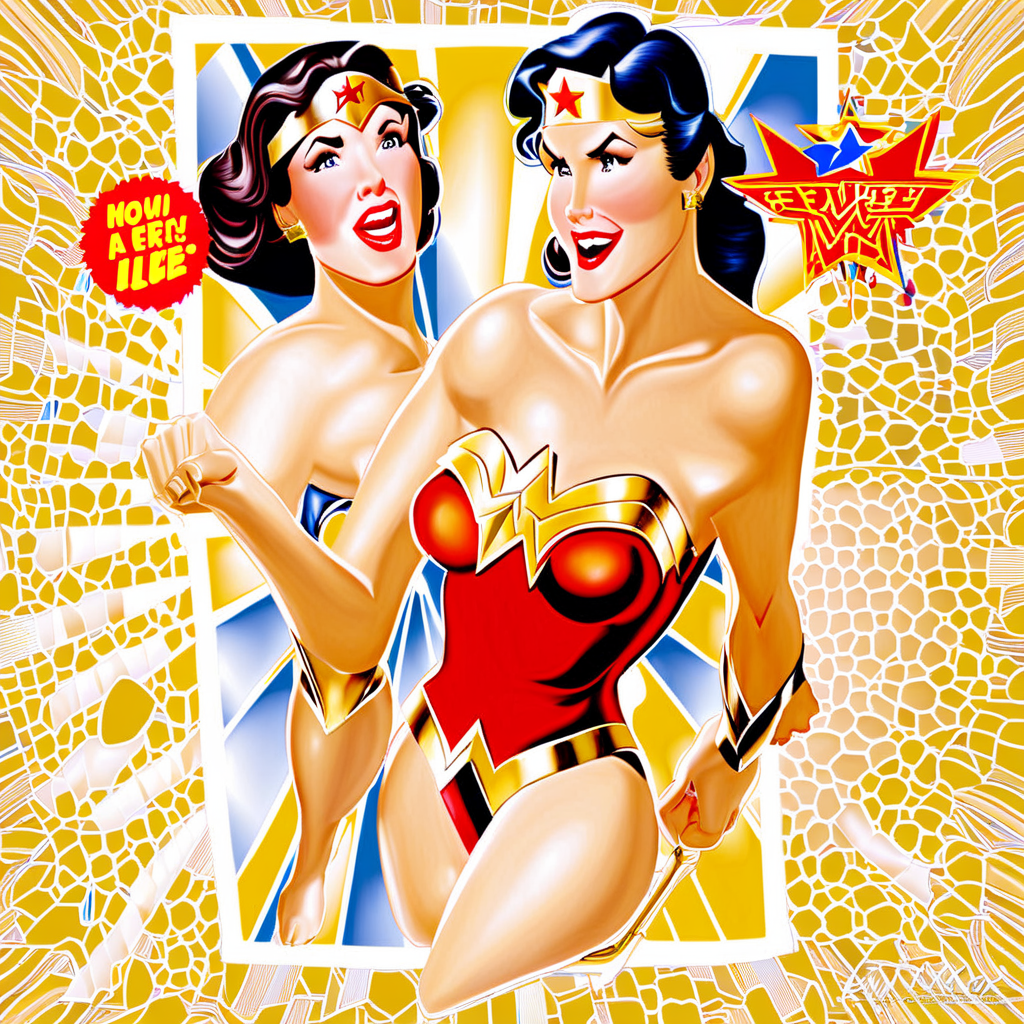

In [ ]:
from diffusers.utils import load_image
from yggdrasill import DiffusionGraphBuilder

b = DiffusionGraphBuilder.from_template("sdxl_text2img", device="cuda")

b.add_component(
    "style_ip",
    "sdxl.ipadapter",
    pretrained="h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter-plus_sdxl_vit-h.safetensors",
)
b.add_component(
    "face_ip",
    "sdxl.ipadapter",
    pretrained="h94/IP-Adapter",
    subfolder="sdxl_models",
    weight_name="ip-adapter-plus-face_sdxl_vit-h.safetensors",
)

style_folder = "https://huggingface.co/datasets/YiYiXu/testing-images/resolve/main/style_ziggy"
style_images = [load_image(f"{style_folder}/img{i}.png") for i in range(10)]
face_image = load_image("https://huggingface.co/datasets/YiYiXu/testing-images/resolve/main/women_input.png")

out = b.run(
    prompt="wonderwoman",
    ip_adapter_image={
        "style_ip": style_images,
        "face_ip": face_image,
    },
    ip_adapter_conditioning_scale={
        "style_ip": 0.7,
        "face_ip": 0.3,
    },
    negative_prompt="monochrome, lowres, bad anatomy, worst quality, low quality",
    seed=42,
)

out.images[0]

### Structural control

In [ ]:
from yggdrasill import DiffusionGraphBuilder

builder = DiffusionGraphBuilder.from_template("sdxl_text2img", device="cuda")
builder.add_component("ControlNetDepth", "sdxl.controlnet", pretrained="diffusers/controlnet-depth-sdxl-1.0")
builder.add_component("IPAdapter", "sdxl.ipadapter", pretrained="h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter_sdxl.bin")

out = builder.run(
    prompt="best quality, high quality",
    negative_prompt="monochrome, lowres, bad anatomy, worst quality, low quality",
    controlnet_image={
        "ControlNetDepth": "https://huggingface.co/datasets/YiYiXu/testing-images/resolve/main/depth.png",
    },
    controlnet_conditioning_scale={
        "ControlNetDepth": 0.9,
    },
    ip_adapter_image={
        "IPAdapter": "https://huggingface.co/datasets/YiYiXu/testing-images/resolve/main/statue.png",
    },
    ip_adapter_conditioning_scale={
        "IPAdapter": 0.9,
    },
)

out.images[0]

### Style and layout control

In [ ]:
instant_style = {
    "down": {"block_2": [0.0, 1.0]},
    "up": {"block_0": [0.0, 1.0, 0.0]},
}

mask_builder = DiffusionGraphBuilder.from_template("sdxl_text2img", device="cuda")
mask_builder.add_component("IPAdapter", "sdxl.ipadapter", pretrained="h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter_sdxl.bin")

out = mask_builder.run(
    prompt="a cat, masterpiece, best quality, high quality",
    ip_adapter_image={
        "IPAdapter": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/0052a70beed5bf71b92610a43a52df6d286cd5f3/diffusers/rabbit.jpg",
    },
    ip_adapter_conditioning_scale=instant_style,
    guidance_scale=5.0,
)

out.images[0]